# Layer 3: Prediction & Forecasting (앞으로 어떻게 될까?)

## Why This Analysis Matters
Reactive dashboards tell you what happened. Forecasting tells you what to prepare for.
For a marketplace operations team, three forward-looking questions dominate:

1. **GMV forecast:** What is next quarter's revenue likely to be?
2. **Seller churn risk:** Which sellers are about to go inactive?
3. **Anomaly detection:** Which current metrics are outside normal bounds?

This notebook addresses all three using Prophet, rule-based scoring, and rolling z-scores.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

orders      = pd.read_csv('../data/olist_orders_dataset.csv',
    parse_dates=['order_purchase_timestamp','order_delivered_customer_date'])
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
customers   = pd.read_csv('../data/olist_customers_dataset.csv')
reviews     = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products    = pd.read_csv('../data/olist_products_dataset.csv')
category_trans = pd.read_csv('../data/product_category_name_translation.csv')

orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
print(f"Date range: {orders['order_purchase_timestamp'].min().date()} "
      f"to {orders['order_purchase_timestamp'].max().date()}")


Date range: 2016-09-04 to 2018-10-17


## 3.1 GMV Forecast with Facebook Prophet

Prophet is well-suited for business time series because it handles:
- Trend changes (e.g., platform growth inflections)
- Weekly / yearly seasonality
- Holiday effects (optional)

We train on observed monthly GMV and forecast 6 months ahead.


In [2]:
from prophet import Prophet

# Build training data
oi = orders.merge(order_items[['order_id','price']], on='order_id')
gmv = (oi[oi['order_status']=='delivered']
       .groupby('month')['price'].sum()
       .reset_index(name='y'))
gmv = gmv.rename(columns={'month':'ds'})
gmv = gmv.iloc[1:-1].copy()  # trim partial months

print(f"Training on {len(gmv)} monthly data points")
print(gmv.tail(6).to_string(index=False))


Importing plotly failed. Interactive plots will not work.


Training on 21 monthly data points
        ds         y
2018-02-01 826437.13
2018-03-01 953356.25
2018-04-01 973534.09
2018-05-01 977544.69
2018-06-01 856077.86
2018-07-01 867953.46


21:12:26 - cmdstanpy - INFO - Chain [1] start processing


21:12:27 - cmdstanpy - INFO - Chain [1] done processing


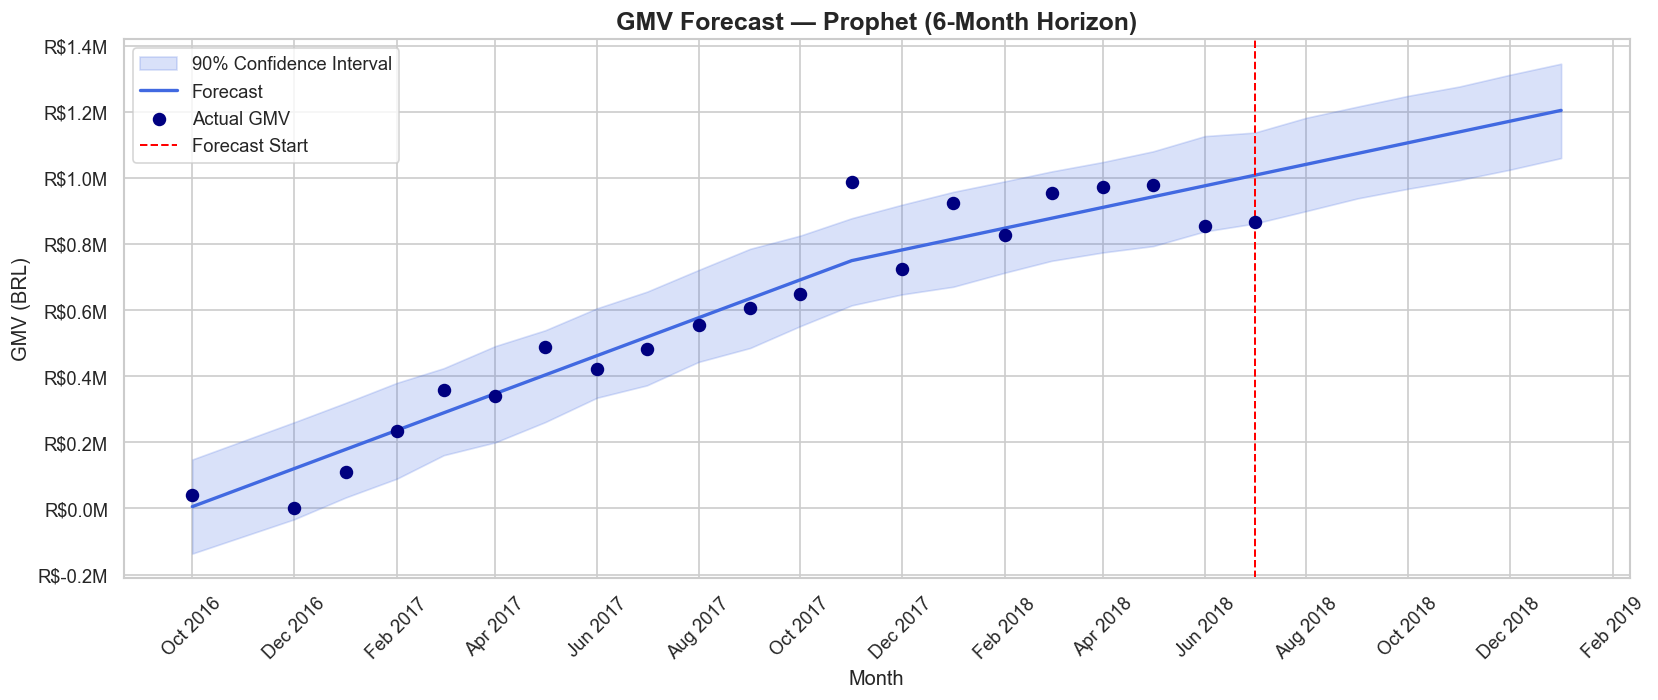


Forecast for next 6 months:
     Month    Forecast Lower (90%) Upper (90%)
2018-08-01 R$1,041,668   R$900,126 R$1,182,578
2018-09-01 R$1,074,751   R$938,723 R$1,216,551
2018-10-01 R$1,106,766   R$967,568 R$1,248,785
2018-11-01 R$1,139,849   R$994,135 R$1,277,230
2018-12-01 R$1,171,864 R$1,024,986 R$1,312,353
2019-01-01 R$1,204,947 R$1,060,480 R$1,346,204


In [3]:
model = Prophet(
    yearly_seasonality=False,  # only ~2 years of data, not enough for yearly
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.15,  # allow moderate flexibility
    seasonality_mode='multiplicative',
    interval_width=0.90
)
model.fit(gmv)

# Forecast 6 months into the future
future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.2, color='royalblue', label='90% Confidence Interval')
ax.plot(forecast['ds'], forecast['yhat'],
        color='royalblue', linewidth=2, label='Forecast')
ax.scatter(gmv['ds'], gmv['y'],
           color='navy', zorder=5, s=50, label='Actual GMV')

# Mark the forecast start
last_date = gmv['ds'].max()
ax.axvline(last_date, color='red', linestyle='--', linewidth=1.2, label='Forecast Start')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_title('GMV Forecast — Prophet (6-Month Horizon)', fontsize=15, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('GMV (BRL)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/gmv_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Print forecast numbers
print("\nForecast for next 6 months:")
future_rows = forecast[forecast['ds'] > last_date][['ds','yhat','yhat_lower','yhat_upper']]
future_rows.columns = ['Month','Forecast','Lower (90%)','Upper (90%)']
for col in ['Forecast','Lower (90%)','Upper (90%)']:
    future_rows[col] = future_rows[col].apply(lambda x: f'R${x:,.0f}')
print(future_rows.to_string(index=False))


## 3.2 Seller Churn Risk Prediction (Rule-Based)

We flag sellers as "at risk" using a simple but effective rule-based approach:

**At-risk seller criteria (any 2 of 3):**
1. Order volume in the last 30 days is ≤50% of their historical monthly average
2. No sales in the last 45 days
3. Average review score < 3.5

This rule-based approach is explainable, easy to operationalize, and appropriate
given the dataset's time range. A more advanced model (logistic regression, XGBoost)
would require labelled churn outcomes from future data.


In [4]:
base = (orders.merge(order_items[['order_id','price','seller_id']], on='order_id')
              .merge(reviews[['order_id','review_score']], on='order_id', how='left'))

cutoff = base['order_purchase_timestamp'].max()
window_30  = cutoff - pd.Timedelta(days=30)
window_45  = cutoff - pd.Timedelta(days=45)
window_hist = cutoff - pd.Timedelta(days=180)  # 6-month historical baseline

# Per-seller stats
seller_stats = base.groupby('seller_id').apply(lambda g: pd.Series({
    'last_order_date':   g['order_purchase_timestamp'].max(),
    'orders_last_30d':   (g['order_purchase_timestamp'] >= window_30).sum(),
    'orders_hist_6m':    (g['order_purchase_timestamp'] >= window_hist).sum(),
    'avg_review':        g['review_score'].mean(),
    'total_orders':      len(g),
})).reset_index()

seller_stats['avg_monthly_hist'] = seller_stats['orders_hist_6m'] / 6
seller_stats['days_since_last']  = (cutoff - seller_stats['last_order_date']).dt.days

# Risk flags
seller_stats['flag_volume_drop'] = (
    (seller_stats['avg_monthly_hist'] > 0) &
    (seller_stats['orders_last_30d'] <= seller_stats['avg_monthly_hist'] * 0.5))
seller_stats['flag_inactive'] = seller_stats['days_since_last'] >= 45
seller_stats['flag_low_review'] = seller_stats['avg_review'] < 3.5

seller_stats['risk_flags'] = (seller_stats['flag_volume_drop'].astype(int) +
                               seller_stats['flag_inactive'].astype(int) +
                               seller_stats['flag_low_review'].astype(int))
seller_stats['churn_risk'] = seller_stats['risk_flags'].map(
    {0:'Low', 1:'Medium', 2:'High', 3:'Critical'})

print("Seller churn risk distribution:")
print(seller_stats['churn_risk'].value_counts().to_string())
print(f"\nAt-risk sellers (High+Critical): "
      f"{(seller_stats['risk_flags'] >= 2).sum():,} "
      f"({(seller_stats['risk_flags'] >= 2).mean()*100:.1f}% of active sellers)")


Seller churn risk distribution:
churn_risk
Medium      1109
Low          936
High         899
Critical     151

At-risk sellers (High+Critical): 1,050 (33.9% of active sellers)


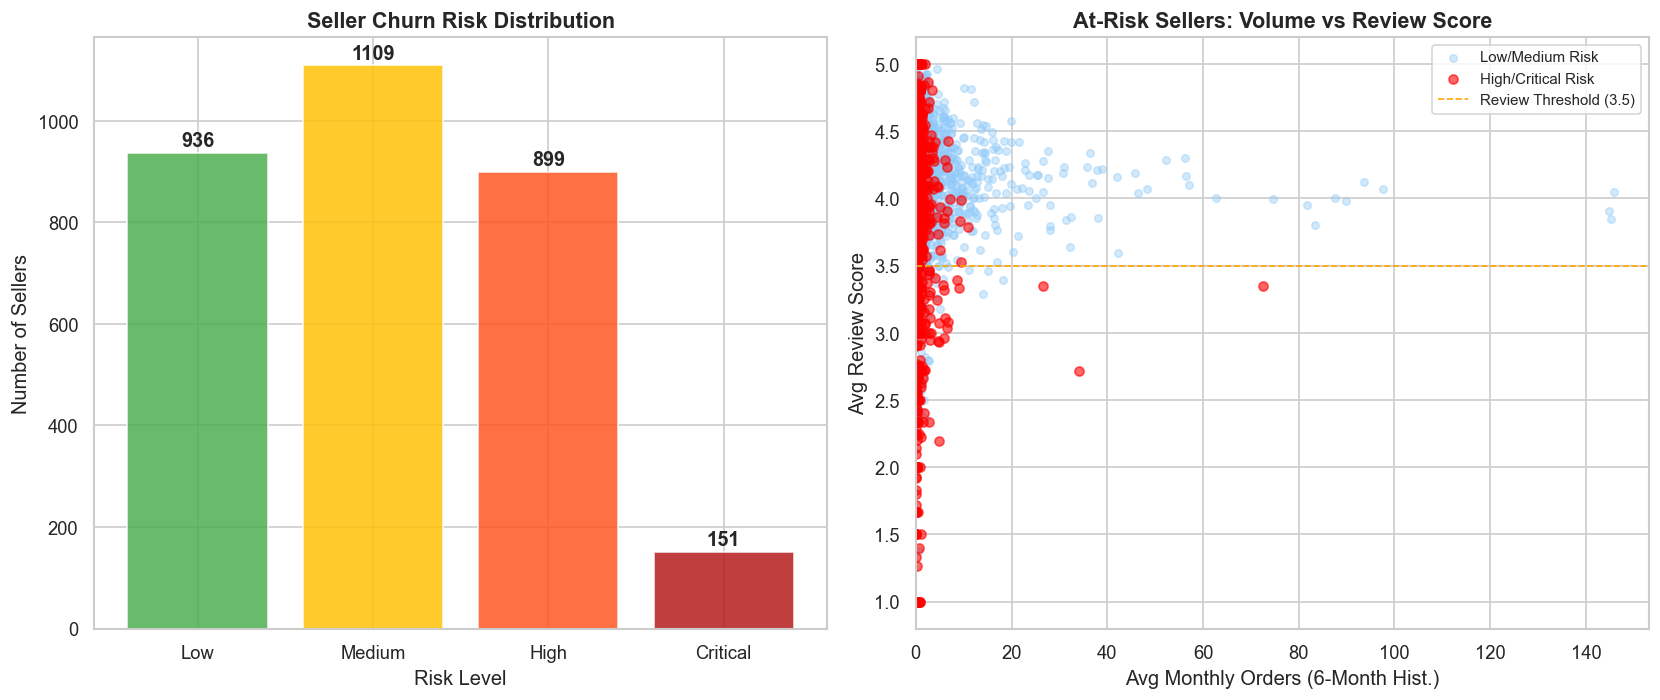


Top 10 At-Risk Sellers:
                       seller_id  days_since_last  orders_last_30d  avg_monthly_hist  avg_review churn_risk
8444e55c1f13cd5c179851e5ca5ebd00               59                0              4.83        3.07   Critical
71271995e85f5b8530be99ed54a91b89               53                0              0.83        2.50   Critical
2c3d56f92f360fb89d849b84e8f50eae              163                0              0.17        3.12   Critical
74bafed391319577bce6f4d2acc0589a              139                0              0.17        2.67   Critical
7494d0dcba8551df6cf37f1b905dc2f7              123                0              0.17        3.00   Critical
a218df5c097b0ca409cfaac1488cc7f6               68                0              0.67        2.75   Critical
2e3be8a987a30d7544dbbda6861cc14e               46                0              1.00        3.05   Critical
2ea0861cc19e94cad86438c984c52da4               47                0              1.00        3.33   Critical
2eb

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Risk distribution
risk_counts = seller_stats['churn_risk'].value_counts()
risk_order = ['Low','Medium','High','Critical']
risk_colors = {'Low':'#4CAF50','Medium':'#FFC107','High':'#FF5722','Critical':'#B71C1C'}
bars = axes[0].bar(
    [r for r in risk_order if r in risk_counts.index],
    [risk_counts.get(r, 0) for r in risk_order],
    color=[risk_colors[r] for r in risk_order if r in risk_counts.index],
    edgecolor='white', alpha=0.85)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Seller Churn Risk Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Number of Sellers')

# Volume drop vs avg review (scatter coloured by risk)
at_risk = seller_stats[seller_stats['risk_flags'] >= 2].copy()
not_risk = seller_stats[seller_stats['risk_flags'] < 2].copy()

axes[1].scatter(not_risk['avg_monthly_hist'], not_risk['avg_review'],
                color='#90CAF9', alpha=0.4, s=20, label='Low/Medium Risk')
axes[1].scatter(at_risk['avg_monthly_hist'], at_risk['avg_review'],
                color='red', alpha=0.6, s=30, label='High/Critical Risk')
axes[1].axhline(3.5, color='orange', linestyle='--', linewidth=1, label='Review Threshold (3.5)')
axes[1].set_xlim(left=0)
axes[1].set_title('At-Risk Sellers: Volume vs Review Score',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Monthly Orders (6-Month Hist.)')
axes[1].set_ylabel('Avg Review Score')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../images/seller_churn_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top 10 highest-risk sellers
high_risk = (seller_stats[seller_stats['risk_flags'] >= 2]
             .sort_values('risk_flags', ascending=False)
             .head(10)[['seller_id','days_since_last','orders_last_30d',
                         'avg_monthly_hist','avg_review','churn_risk']]
             .round(2))
print("\nTop 10 At-Risk Sellers:")
print(high_risk.to_string(index=False))


## 3.3 Anomaly Detection Dashboard — Rolling Z-Score

We apply rolling z-score anomaly detection across four key metrics simultaneously.
This is the same method used in Layer 1 for GMV, now extended to:
- Monthly active buyers
- Monthly active sellers
- Completion rate
- Avg review score

The purpose is to give an on-call team a single view of which metrics are currently outside normal operating range.


In [6]:
# Build all four monthly metrics
orders_cust = orders.merge(
    customers[['customer_id','customer_unique_id']], on='customer_id')
active_buyers = (orders_cust.groupby('month')['customer_unique_id']
                 .nunique().reset_index(name='active_buyers'))

orders_sell = orders.merge(order_items[['order_id','seller_id']], on='order_id')
active_sellers = (orders_sell.groupby('month')['seller_id']
                  .nunique().reset_index(name='active_sellers'))

orders_oi = orders.merge(order_items[['order_id','price']], on='order_id')
gmv_m = (orders_oi[orders_oi['order_status']=='delivered']
         .groupby('month')['price'].sum().reset_index(name='gmv'))

comp = (orders.groupby('month')
        .apply(lambda x: (x['order_status']=='delivered').sum() / len(x))
        .reset_index(name='completion_rate'))

rev_m = (orders.merge(reviews[['order_id','review_score']], on='order_id', how='left')
         .groupby('month')['review_score'].mean().reset_index(name='avg_review'))

metrics_df = (gmv_m.merge(active_buyers, on='month')
                    .merge(active_sellers, on='month')
                    .merge(comp, on='month')
                    .merge(rev_m, on='month')
                    .iloc[1:-1].reset_index(drop=True))

# Compute rolling z-score for each metric
WINDOW = 4
metric_cols = ['gmv','active_buyers','active_sellers','completion_rate','avg_review']
metric_labels = ['GMV','Active Buyers','Active Sellers','Completion Rate','Avg Review']

for col in metric_cols:
    metrics_df[f'{col}_roll_mean'] = metrics_df[col].rolling(WINDOW, center=True, min_periods=2).mean()
    metrics_df[f'{col}_roll_std']  = metrics_df[col].rolling(WINDOW, center=True, min_periods=2).std()
    metrics_df[f'{col}_z']         = ((metrics_df[col] - metrics_df[f'{col}_roll_mean'])
                                       / metrics_df[f'{col}_roll_std'])
    metrics_df[f'{col}_anomaly']   = metrics_df[f'{col}_z'].abs() > 2

print("Anomaly detections per metric:")
for col, label in zip(metric_cols, metric_labels):
    n = metrics_df[f'{col}_anomaly'].sum()
    print(f"  {label}: {n} anomalous months")


Anomaly detections per metric:
  GMV: 0 anomalous months
  Active Buyers: 0 anomalous months
  Active Sellers: 0 anomalous months
  Completion Rate: 0 anomalous months
  Avg Review: 0 anomalous months


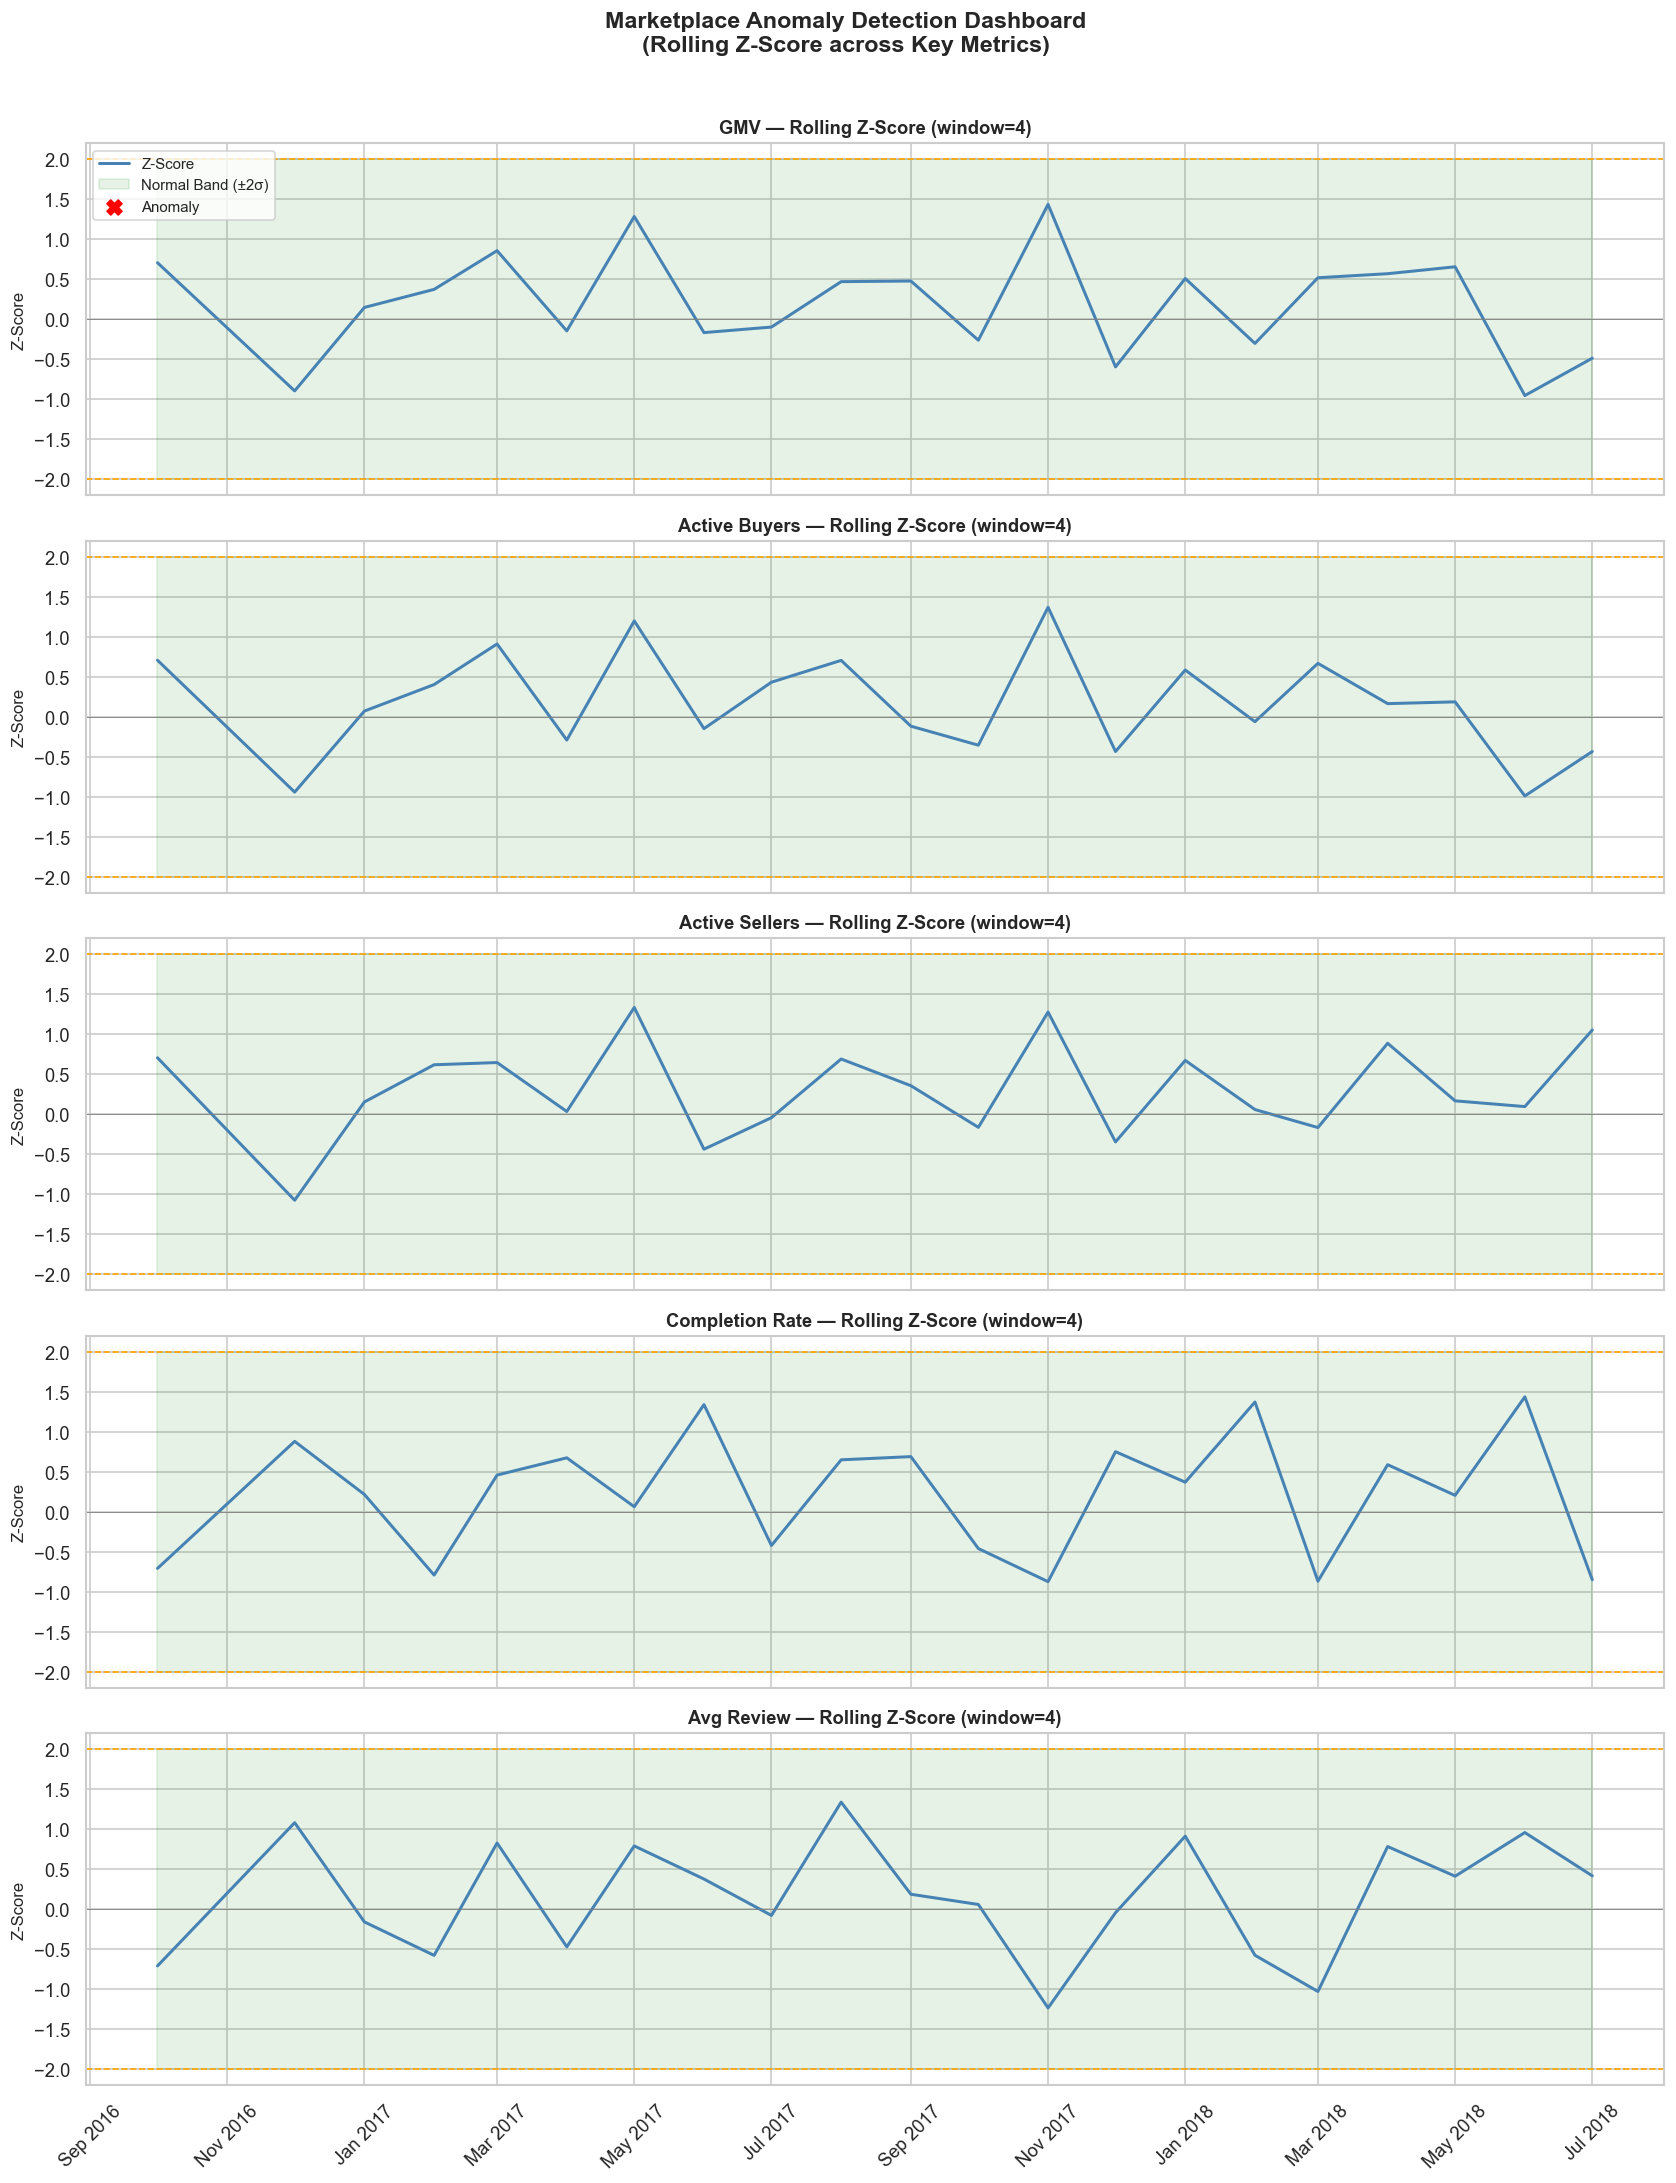

In [7]:
fig, axes = plt.subplots(len(metric_cols), 1, figsize=(14, 18), sharex=True)

for i, (col, label) in enumerate(zip(metric_cols, metric_labels)):
    ax = axes[i]
    ax.plot(metrics_df['month'], metrics_df[f'{col}_z'],
            color='steelblue', linewidth=1.8, label='Z-Score')
    ax.fill_between(metrics_df['month'], -2, 2, alpha=0.1, color='green',
                    label='Normal Band (±2σ)')
    ax.axhline( 2, color='orange', linestyle='--', linewidth=1)
    ax.axhline(-2, color='orange', linestyle='--', linewidth=1)
    ax.axhline( 0, color='gray', linestyle='-', linewidth=0.5)

    anomalies = metrics_df[metrics_df[f'{col}_anomaly']]
    ax.scatter(anomalies['month'], anomalies[f'{col}_z'],
               color='red', zorder=5, s=80, marker='X', label='Anomaly')

    ax.set_ylabel('Z-Score', fontsize=10)
    ax.set_title(f'{label} — Rolling Z-Score (window={WINDOW})',
                 fontsize=11, fontweight='bold')
    if i == 0:
        ax.legend(loc='upper left', fontsize=9)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Marketplace Anomaly Detection Dashboard\n(Rolling Z-Score across Key Metrics)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../images/anomaly_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## Layer 3 Forecasting Summary

| Output | Method | Key Output |
|--------|--------|-----------|
| GMV Forecast | Facebook Prophet | 6-month projection with 90% CI |
| Seller Churn Risk | Rule-based (3-flag scoring) | High/Critical risk seller list |
| Anomaly Dashboard | Rolling z-score (window=4) | All metrics, alert at \|z\| > 2 |

**Operational workflow:**
1. Run anomaly dashboard weekly — if any metric has |z| > 2, escalate
2. Run seller churn risk monthly — export High/Critical list for retention team
3. Update GMV forecast quarterly — adjust targets if lower bound trends down

→ **Use `04_two_sided_market.ipynb` to understand cross-side effects.**
